<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/U1_overall_Generator_analyse_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False



In [ ]:
# =========================================================
# 1. FILE PATHS
# =========================================================

base = Path("/content")

files = {
    "electric": base / "UNIT1_electric_28_4_2026_R2.csv",
    "cool": base / "UNIT1_cool_28_4_2026_R2.csv",
    "winding1": base / "UNIT1_winding1_28_4_2026_R2.csv",
    "winding2": base / "UNIT1_winding2_28_4_2026_R2.csv",
    "core": base / "UNIT1_Core_Pad_28_4_2026_R2.csv",
    "pad": base / "UNIT1_Pad_Pad_28_4_2026_R2.csv",
    "air": base / "UNIT1_Air_Pad_28_4_2026_R2.csv",
}

output_dir = Path("UNIT1_generator_general_analysis_outputs")
output_dir.mkdir(exist_ok=True)

In [ ]:
# =========================================================
# 2. READ FILES
# =========================================================

def read_clean(path):
    print(f"Attempting to read file: {path.name}")
    df = pd.DataFrame()

    # Attempt 1: UTF-16 with tab delimiter (common for some exports)
    try:
        df = pd.read_csv(path, encoding="utf-16", sep='\t', engine='python')
        print(f"DEBUG: Successfully read {path.name} with utf-16, sep='\t'. Initial shape: {df.shape}")
    except Exception as e_utf16_tab:
        print(f"DEBUG: Failed to read {path.name} with utf-16, sep='\t'. Error: {e_utf16_tab}")
        # Attempt 2: UTF-16 with comma delimiter
        try:
            df = pd.read_csv(path, encoding="utf-16", sep=',', engine='python')
            print(f"DEBUG: Successfully read {path.name} with utf-16, sep=','. Initial shape: {df.shape}")
        except Exception as e_utf16_comma:
            print(f"DEBUG: Failed to read {path.name} with utf-16, sep=',. Error: {e_utf16_comma}")
            # Attempt 3: Latin1 with inferred separator
            try:
                df = pd.read_csv(path, encoding="latin1", sep=None, engine='python')
                print(f"DEBUG: Successfully read {path.name} with latin1, sep=None. Initial shape: {df.shape}")
            except Exception as e_latin1_infer:
                print(f"DEBUG: Failed to read {path.name} with latin1, sep=None. Error: {e_latin1_infer}")
                # Attempt 4: Latin1 with comma separator
                try:
                    df = pd.read_csv(path, encoding="latin1", sep=",")
                    print(f"DEBUG: Successfully read {path.name} with latin1, sep=',. Initial shape: {df.shape}")
                except Exception as e_latin1_comma:
                    print(f"DEBUG: Failed to read {path.name} with latin1, sep=',. Error: {e_latin1_comma}")
                    print(f"Warning: All attempts to read {path.name} failed. Returning empty DataFrame.")
                    return pd.DataFrame(columns=['Timestamp'])

    # Clean column names by removing null characters and stripping whitespace
    df.columns = df.columns.str.replace('\x00', '')
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Debugging: Print columns to identify the correct timestamp column
    print(f"Columns for {path.name} after cleaning: {df.columns.tolist()}")

    # Rename 'ÿþTimestamp', 'ÿþT', or 'T' to 'Timestamp' if it exists after cleaning
    if 'ÿþTimestamp' in df.columns:
        df = df.rename(columns={'ÿþTimestamp': 'Timestamp'})
    elif 'ÿþT' in df.columns:
        df = df.rename(columns={'ÿþT': 'Timestamp'})
    elif 'T' in df.columns:
        df = df.rename(columns={'T': 'Timestamp'})

    # After potential renames, check if 'Timestamp' column exists before proceeding
    if 'Timestamp' not in df.columns:
        print(f"Warning: 'Timestamp' column not found or identified for {path.name}. Dataframe might be incomplete or empty.")
        # If Timestamp column is missing, it's problematic. Let's return an empty df to prevent further errors.
        return pd.DataFrame(columns=['Timestamp']) # Ensure 'Timestamp' column exists even if empty

    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"])
    df = df.sort_values("Timestamp").reset_index(drop=True)

    for c in df.columns:
        if c != "Timestamp":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


dfs = {name: read_clean(path) for name, path in files.items()}

print("Loaded files:")
for name, d in dfs.items():
    print(name, d.shape)

Attempting to read file: UNIT1_electric_28_4_2026_R2.csv
DEBUG: Successfully read UNIT1_electric_28_4_2026_R2.csv with utf-16, sep='	'. Initial shape: (996, 12)
Columns for UNIT1_electric_28_4_2026_R2.csv after cleaning: ['Timestamp', 'ACTIVE POWER MEAS VALUE', 'UNIT REACTIVE POWER', 'UNIT VOLTAGE PHASE AB', 'UNIT VOLTAGE PHASE BC', 'UNIT VOLTAGE PHASE CA', 'UNIT CURRENT PHASE A', 'UNIT CURRENT PHASE B', 'UNIT CURRENT PHASE C', 'FIELD CURRENT', 'FIELD VOLTAGE', 'UNIT FREQUENCY']
Attempting to read file: UNIT1_cool_28_4_2026_R2.csv
DEBUG: Successfully read UNIT1_cool_28_4_2026_R2.csv with utf-16, sep='	'. Initial shape: (996, 9)
Columns for UNIT1_cool_28_4_2026_R2.csv after cleaning: ['Timestamp', 'UPPER BEARING OIL COOLER WATER OUTLET TEMP', 'GENERATOR COOLING WATER INLET TEMP', 'GENERATOR COOLING WATER OUTLET TEMP', 'LOWER BEARING OIL COOLER WATER OUTLET TEMP', 'UNIT#1 COOLING WATER TEMPERATURE', 'UNIT#1 COOLING WATER TEMPERATURE.1', 'COOLING WATER PRESSURE', 'UNIT#1 COOLING WATER FLO

In [ ]:

# =========================================================
# 3. MERGE ALL FILES BY TIMESTAMP
# =========================================================

df = dfs["electric"].copy()

for name in ["cool", "winding1", "winding2", "core", "pad", "air"]:
    df = pd.merge_asof(
        df.sort_values("Timestamp"),
        dfs[name].sort_values("Timestamp"),
        on="Timestamp",
        direction="nearest",
        tolerance=pd.Timedelta("10min"),
        suffixes=("", f"_{name}")
    )

print("Merged shape:", df.shape)


Merged shape: (993, 74)


In [ ]:
# =========================================================
# 4. AUTO-DETECT SENSOR GROUPS
# =========================================================

mw_col = "ACTIVE POWER MEAS VALUE"
mvar_col = "REACTIVE POWER MEAS VALUE"

voltage_cols = [c for c in df.columns if "Voltage" in c or "VOLTAGE" in c]
current_cols = [c for c in df.columns if "CURRENT PHASE" in c]
field_current_col = "FIELD CURRENT"
field_voltage_col = "FIELD VOLTAGE"

winding_cols = [c for c in df.columns if "STATOR WINDING" in c]
core_cols = [c for c in df.columns if "STATOR  CORE" in c or "STATOR CORE" in c]

upper_bearing_cols = [c for c in df.columns if "UPPER" in c and "BEARING" in c and "TEMP" in c]
lower_bearing_cols = [c for c in df.columns if "LOWER" in c and "BEARING" in c and "TEMP" in c]
thrust_bearing_cols = [c for c in df.columns if "THRUST" in c and "BEARING" in c and "TEMP" in c]
bearing_cols = upper_bearing_cols + lower_bearing_cols + thrust_bearing_cols

hot_air_cols = [c for c in df.columns if "HOT AIR" in c]
cold_air_cols = [c for c in df.columns if "COLD AIR" in c]

water_in_col = "GENERATOR COOLING WATER INLET TEMP"
water_out_col = "GENERATOR COOLING WATER OUTLET TEMP"
water_flow_col = "COOLING WATER FLOW"
water_pressure_col = "COOLING WATER PRESSURE"

print("\nDetected winding sensors:", len(winding_cols))
print(winding_cols)
print("\nDetected core sensors:", len(core_cols))
print(core_cols)
print("\nDetected bearing/pad sensors:", len(bearing_cols))
print(bearing_cols)
print("\nDetected hot air sensors:", hot_air_cols)
print("Detected cold air sensors:", cold_air_cols)



Detected winding sensors: 18
['STATOR WINDING PHASE U1 TEMP', 'STATOR WINDING PHASE W14 TEMP', 'STATOR WINDING PHASE V26 TEMP', 'STATOR WINDING PHASE U56 TEMP', 'STATOR WINDING PHASE W68 TEMP', 'STATOR WINDING PHASE V80 TEMP', 'STATOR WINDING PHASE U110 TEMP', 'STATOR WINDING PHASE W122 TEMP', 'STATOR WINDING PHASE V134 TEMP', 'STATOR WINDING PHASE U164 TEMP', 'STATOR WINDING PHASE W176 TEMP', 'STATOR WINDING PHASE V188 TEMP', 'STATOR WINDING PHASE U218 TEMP', 'STATOR WINDING PHASE W230 TEMP', 'STATOR WINDING PHASE V242 TEMP', 'STATOR WINDING PHASE U272 TEMP', 'STATOR WINDING PHASE W284 TEMP', 'STATOR WINDING PHASE V296 TEMP']

Detected core sensors: 4
['STATOR  CORE TEMP', 'STATOR  CORE TEMP.1', 'STATOR  CORE TEMP.2', 'STATOR  CORE TEMP.3']

Detected bearing/pad sensors: 15
['UPPER BEARING OIL COOLER WATER OUTLET TEMP', 'UPPER GUIDE BEARING PAD TEMP', 'UPPER GUIDE BEARING PAD TEMP.1', 'UPPER GUIDE BEARING PAD TEMP.2', 'UPPER BEARING OIL SUMP TEMP', 'UPPER BEARING OIL SUMP TEMP.1', 'L

In [ ]:
# =========================================================
# 5. BASIC CLEANING
# =========================================================

# FIX: Correcting the reactive power column name
mvar_col = "UNIT REACTIVE POWER"

required = [mw_col, mvar_col] + winding_cols

missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = df.dropna(subset=[mw_col, mvar_col])
df = df[df[mw_col] > 20].copy()

df["MW_diff_abs"] = df[mw_col].diff().abs()
analysis_df = df[
    (df[mw_col] > 20) &
    (df["MW_diff_abs"].fillna(0) < 15)
].copy()

analysis_df = analysis_df.sort_values("Timestamp").reset_index(drop=True)


In [ ]:
# =========================================================
# 6. ELECTRICAL FEATURES
# =========================================================

analysis_df["MW"] = analysis_df[mw_col]
analysis_df["MVAr"] = analysis_df[mvar_col]
analysis_df["MVAr_abs"] = analysis_df["MVAr"].abs()

if len(current_cols) >= 3:
    analysis_df["I_mean"] = analysis_df[current_cols].mean(axis=1)
    analysis_df["I_max"] = analysis_df[current_cols].max(axis=1)
    analysis_df["I_min"] = analysis_df[current_cols].min(axis=1)
    analysis_df["I_mean_sq"] = analysis_df["I_mean"] ** 2
    analysis_df["Copper_loss_proxy"] = (analysis_df[current_cols] ** 2).sum(axis=1)
    analysis_df["I_imbalance_fast_pct"] = np.where(
        analysis_df["I_mean"] != 0,
        (analysis_df["I_max"] - analysis_df["I_min"]) / analysis_df["I_mean"] * 100,
        np.nan
    )

if len(voltage_cols) >= 3:
    analysis_df["V_mean_kV"] = analysis_df[voltage_cols].mean(axis=1)

if field_current_col in analysis_df.columns:
    analysis_df["Field_Current"] = analysis_df[field_current_col]
    analysis_df["Field_Current_sq"] = analysis_df["Field_Current"] ** 2
else:
    analysis_df["Field_Current"] = np.nan

if field_voltage_col in analysis_df.columns:
    analysis_df["Field_Voltage"] = analysis_df[field_voltage_col]
else:
    analysis_df["Field_Voltage"] = np.nan

analysis_df["MVA"] = np.sqrt(analysis_df["MW"]**2 + analysis_df["MVAr"]**2)
analysis_df["PF_abs"] = np.where(
    analysis_df["MVA"] != 0,
    abs(analysis_df["MW"]) / analysis_df["MVA"],
    np.nan
)

analysis_df["PF_dev"] = 1 - analysis_df["PF_abs"]
analysis_df["MW_x_MVAr"] = analysis_df["MW"] * analysis_df["MVAr_abs"]


In [ ]:
# =========================================================
# 7. WINDING THERMAL FEATURES
# =========================================================

analysis_df["Winding_Avg"] = analysis_df[winding_cols].mean(axis=1)
analysis_df["Winding_Max"] = analysis_df[winding_cols].max(axis=1)
analysis_df["Winding_Min"] = analysis_df[winding_cols].min(axis=1)
analysis_df["Winding_Spread"] = analysis_df["Winding_Max"] - analysis_df["Winding_Min"]
analysis_df["Winding_Std"] = analysis_df[winding_cols].std(axis=1)
analysis_df["Winding_Hotspot_Sensor"] = analysis_df[winding_cols].idxmax(axis=1)

temp_dev_abs = analysis_df[winding_cols].sub(analysis_df["Winding_Avg"], axis=0).abs()
analysis_df["Worst_Winding_Deviation"] = temp_dev_abs.max(axis=1)
analysis_df["Worst_Winding_Deviation_Sensor"] = temp_dev_abs.idxmax(axis=1)


/tmp/ipykernel_8985/3015570225.py:10: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  analysis_df["Winding_Hotspot_Sensor"] = analysis_df[winding_cols].idxmax(axis=1)
/tmp/ipykernel_8985/3015570225.py:14: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  analysis_df["Worst_Winding_Deviation_Sensor"] = temp_dev_abs.idxmax(axis=1)


In [ ]:
# =========================================================
# 8. CORE / BEARING / AIR / WATER FEATURES
# =========================================================

if core_cols:
    analysis_df["Core_Avg"] = analysis_df[core_cols].mean(axis=1)
    analysis_df["Core_Max"] = analysis_df[core_cols].max(axis=1)
    analysis_df["Core_Spread"] = analysis_df[core_cols].max(axis=1) - analysis_df[core_cols].min(axis=1)
else:
    analysis_df["Core_Avg"] = np.nan
    analysis_df["Core_Max"] = np.nan
    analysis_df["Core_Spread"] = np.nan

if bearing_cols:
    analysis_df["Bearing_Avg"] = analysis_df[bearing_cols].mean(axis=1)
    analysis_df["Bearing_Max"] = analysis_df[bearing_cols].max(axis=1)
else:
    analysis_df["Bearing_Avg"] = np.nan
    analysis_df["Bearing_Max"] = np.nan

if upper_bearing_cols:
    analysis_df["Upper_Bearing_Max"] = analysis_df[upper_bearing_cols].max(axis=1)
if lower_bearing_cols:
    analysis_df["Lower_Bearing_Max"] = analysis_df[lower_bearing_cols].max(axis=1)
if thrust_bearing_cols:
    analysis_df["Thrust_Bearing_Max"] = analysis_df[thrust_bearing_cols].max(axis=1)

if hot_air_cols:
    analysis_df["Hot_Air_Avg"] = analysis_df[hot_air_cols].mean(axis=1)
else:
    analysis_df["Hot_Air_Avg"] = np.nan

if cold_air_cols:
    analysis_df["Cold_Air_Avg"] = analysis_df[cold_air_cols].mean(axis=1)
else:
    analysis_df["Cold_Air_Avg"] = np.nan

analysis_df["Air_DeltaT"] = analysis_df["Hot_Air_Avg"] - analysis_df["Cold_Air_Avg"]

if water_in_col in analysis_df.columns:
    analysis_df["Water_Inlet"] = analysis_df[water_in_col]
else:
    analysis_df["Water_Inlet"] = np.nan

if water_out_col in analysis_df.columns:
    analysis_df["Water_Outlet"] = analysis_df[water_out_col]
else:
    analysis_df["Water_Outlet"] = np.nan

if water_flow_col in analysis_df.columns:
    analysis_df["Water_Flow"] = analysis_df[water_flow_col]
else:
    analysis_df["Water_Flow"] = np.nan

if water_pressure_col in analysis_df.columns:
    analysis_df["Water_Pressure"] = analysis_df[water_pressure_col]
else:
    analysis_df["Water_Pressure"] = np.nan

analysis_df["Water_DeltaT"] = analysis_df["Water_Outlet"] - analysis_df["Water_Inlet"]

analysis_df["Water_Flow_kg_s"] = analysis_df["Water_Flow"] * 1000 / 3600
analysis_df["Cooling_Heat_Removal_kW"] = (
    analysis_df["Water_Flow_kg_s"] * 4.186 * analysis_df["Water_DeltaT"]
)

analysis_df["Cooling_kW_per_MW"] = analysis_df["Cooling_Heat_Removal_kW"] / analysis_df["MW"]

analysis_df["TempRise_Avg_vs_Water"] = analysis_df["Winding_Avg"] - analysis_df["Water_Inlet"]
analysis_df["TempRise_Max_vs_Water"] = analysis_df["Winding_Max"] - analysis_df["Water_Inlet"]
analysis_df["TempRise_Avg_vs_ColdAir"] = analysis_df["Winding_Avg"] - analysis_df["Cold_Air_Avg"]

analysis_df["Cooling_Index_Water"] = analysis_df["TempRise_Avg_vs_Water"] / analysis_df["MW"]
analysis_df["Cooling_Index_Air"] = analysis_df["TempRise_Avg_vs_ColdAir"] / analysis_df["MW"]


In [ ]:

# =========================================================
# 9. THERMAL INERTIA FEATURES
# =========================================================

for lag in [1, 2, 3, 6]:
    analysis_df[f"TempRise_lag{lag}"] = analysis_df["TempRise_Avg_vs_Water"].shift(lag)

for lag in [1, 2, 3]:
    analysis_df[f"MW_lag{lag}"] = analysis_df["MW"].shift(lag)
    analysis_df[f"MVAr_lag{lag}"] = analysis_df["MVAr"].shift(lag)
    analysis_df[f"Field_Current_lag{lag}"] = analysis_df["Field_Current"].shift(lag)
    if "I_mean" in analysis_df.columns:
        analysis_df[f"I_mean_lag{lag}"] = analysis_df["I_mean"].shift(lag)

analysis_df["TempRise_ewm"] = analysis_df["TempRise_Avg_vs_Water"].ewm(span=10, adjust=False).mean().shift(1)

analysis_df["dMW"] = analysis_df["MW"].diff()
analysis_df["dMVAr"] = analysis_df["MVAr"].diff()
analysis_df["dField_Current"] = analysis_df["Field_Current"].diff()


In [ ]:

# =========================================================
# 10. BINS
# =========================================================

analysis_df["MW_bin_10"] = pd.cut(analysis_df["MW"], bins=np.arange(20, 181, 10), right=False)
analysis_df["MVAr_bin_10"] = pd.cut(analysis_df["MVAr"], bins=np.arange(-100, 101, 10), right=False)
analysis_df["Water_Inlet_bin"] = pd.cut(analysis_df["Water_Inlet"], bins=np.arange(0, 40, 2), right=False)

analysis_df["High_MVAr_Zone"] = analysis_df["MVAr_abs"] > analysis_df["MVAr_abs"].quantile(0.90)


In [ ]:
# =========================================================
# 11. HEALTH SCORE
# =========================================================

def score_low_good(value, good, bad):
    if pd.isna(value):
        return np.nan
    if value <= good:
        return 100
    if value >= bad:
        return 0
    return 100 * (bad - value) / (bad - good)

analysis_df["Score_Winding_Max"] = analysis_df["Winding_Max"].apply(lambda x: score_low_good(x, 65, 95))
analysis_df["Score_Winding_Spread"] = analysis_df["Winding_Spread"].apply(lambda x: score_low_good(x, 3, 12))
analysis_df["Score_Core"] = analysis_df["Core_Max"].apply(lambda x: score_low_good(x, 60, 90))
analysis_df["Score_Bearing"] = analysis_df["Bearing_Max"].apply(lambda x: score_low_good(x, 70, 90))
analysis_df["Score_Cooling_Index"] = analysis_df["Cooling_Index_Water"].apply(lambda x: score_low_good(x, 0.25, 0.50))

analysis_df["Generator_Thermal_Health_Score"] = analysis_df[
    [
        "Score_Winding_Max",
        "Score_Winding_Spread",
        "Score_Core",
        "Score_Bearing",
        "Score_Cooling_Index",
    ]
].mean(axis=1)


In [ ]:
# =========================================================
# 12. PLOT FUNCTIONS
# =========================================================

def save_time(y_cols, labels, ylabel, title, filename):
    plt.figure(figsize=(14, 5))
    for col, label in zip(y_cols, labels):
        if col in analysis_df.columns:
            plt.plot(analysis_df["Timestamp"], analysis_df[col], label=label)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_scatter(df_, x, y, xlabel, ylabel, title, filename):
    plot_df = df_[[x, y]].dropna()
    plt.figure(figsize=(8, 6))
    plt.scatter(plot_df[x], plot_df[y], s=18, alpha=0.65)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_scatter_colored(df_, x, y, c, xlabel, ylabel, clabel, title, filename):
    plot_df = df_[[x, y, c]].dropna().copy()
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        plot_df[x],
        plot_df[y],
        c=plot_df[c],
        s=18,
        alpha=0.7,
        cmap="viridis"
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    cb = plt.colorbar(sc)
    cb.set_label(clabel)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_time_trend(df_, y_cols, labels, ylabel, title, filename):
    plt.figure(figsize=(14, 5))
    for col, label in zip(y_cols, labels):
        plt.plot(df_["Timestamp"], df_[col], label=label)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_hexbin(df_, x, y, xlabel, ylabel, title, filename, gridsize=28):
    plot_df = df_[[x, y]].dropna().copy()
    plt.figure(figsize=(8, 6))
    hb = plt.hexbin(plot_df[x], plot_df[y], gridsize=gridsize, mincnt=1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    cb = plt.colorbar(hb)
    cb.set_label("Point density")
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_hist(series, xlabel, title, filename, bins=40):
    s = pd.Series(series).dropna()
    plt.figure(figsize=(8, 6))
    plt.hist(s, bins=bins, alpha=0.8)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_boxplot_by_bin(df_, bin_col, y_col, xlabel, ylabel, title, filename):
    plot_df = df_[[bin_col, y_col]].dropna().copy()
    cats = plot_df[bin_col].astype(str)
    groups = [plot_df.loc[cats == c, y_col].values for c in cats.unique()]
    labels = list(cats.unique())

    plt.figure(figsize=(12, 6))
    plt.boxplot(groups, labels=labels, showfliers=True)
    plt.xticks(rotation=45)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_heatmap_from_bins(df_, x_bin_col, y_bin_col, value_col, title, filename):
    plot_df = df_[[x_bin_col, y_bin_col, value_col]].dropna().copy()
    heat = plot_df.pivot_table(
        index=y_bin_col,
        columns=x_bin_col,
        values=value_col,
        aggfunc="mean"
    )
    plt.figure(figsize=(12, 7))
    plt.imshow(heat, aspect="auto", origin="lower")
    plt.colorbar(label=f"Mean {value_col}")
    plt.title(title)
    plt.xlabel(x_bin_col)
    plt.ylabel(y_bin_col)
    plt.xticks(range(len(heat.columns)), [str(c) for c in heat.columns], rotation=45, ha="right")
    plt.yticks(range(len(heat.index)), [str(i) for i in heat.index])
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_line_by_group(df_, x_col, y_col, group_col, xlabel, ylabel, title, filename):
    plot_df = df_[[x_col, y_col, group_col]].dropna().copy()
    grp = (
        plot_df.groupby([x_col, group_col], observed=False)[y_col]
        .mean()
        .reset_index()
        .sort_values([group_col, x_col])
    )

    plt.figure(figsize=(10, 6))
    for g, sub in grp.groupby(group_col, observed=False):
        plt.plot(sub[x_col], sub[y_col], marker="o", label=str(g))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(title=group_col)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

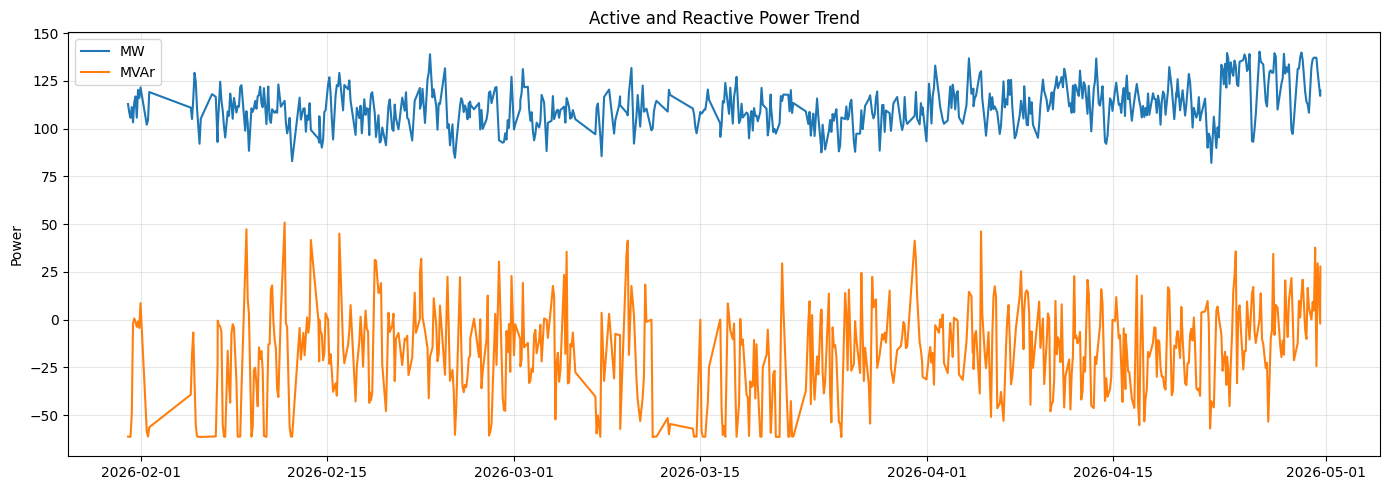

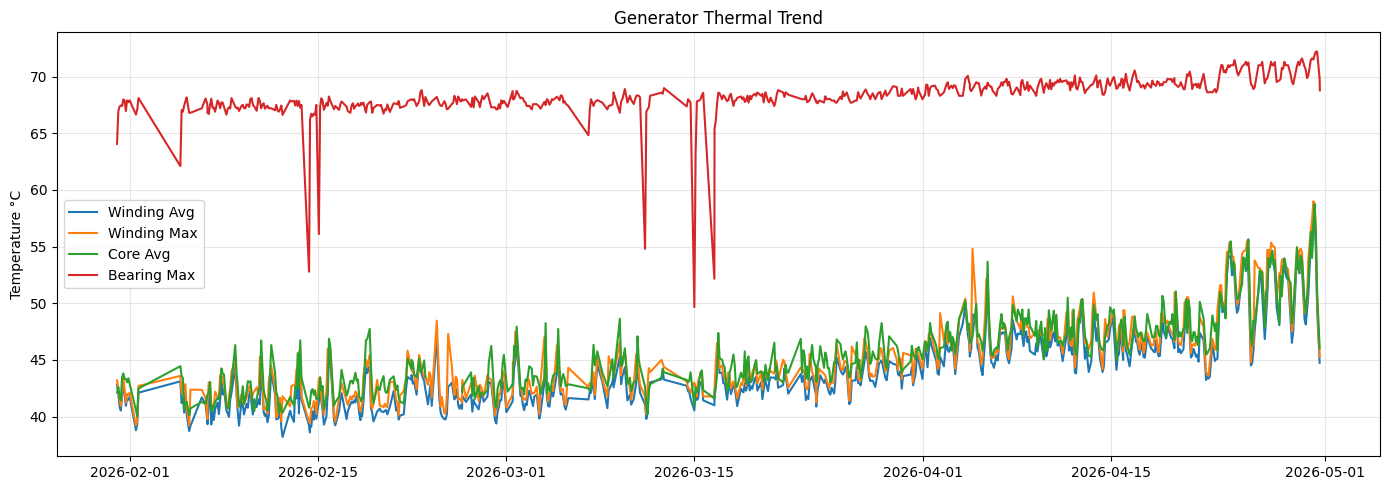

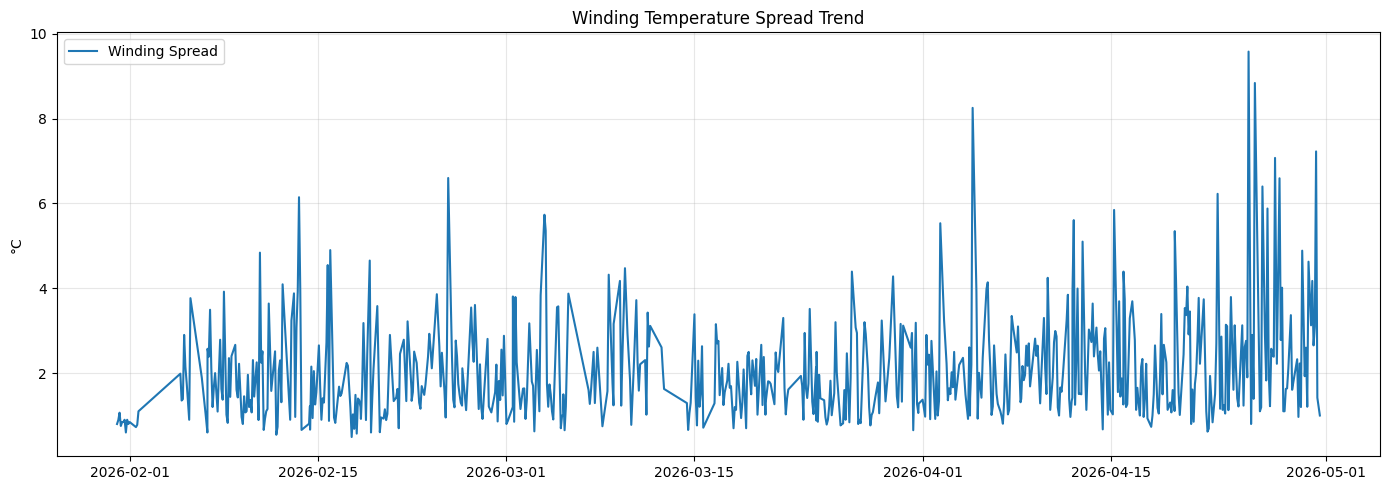

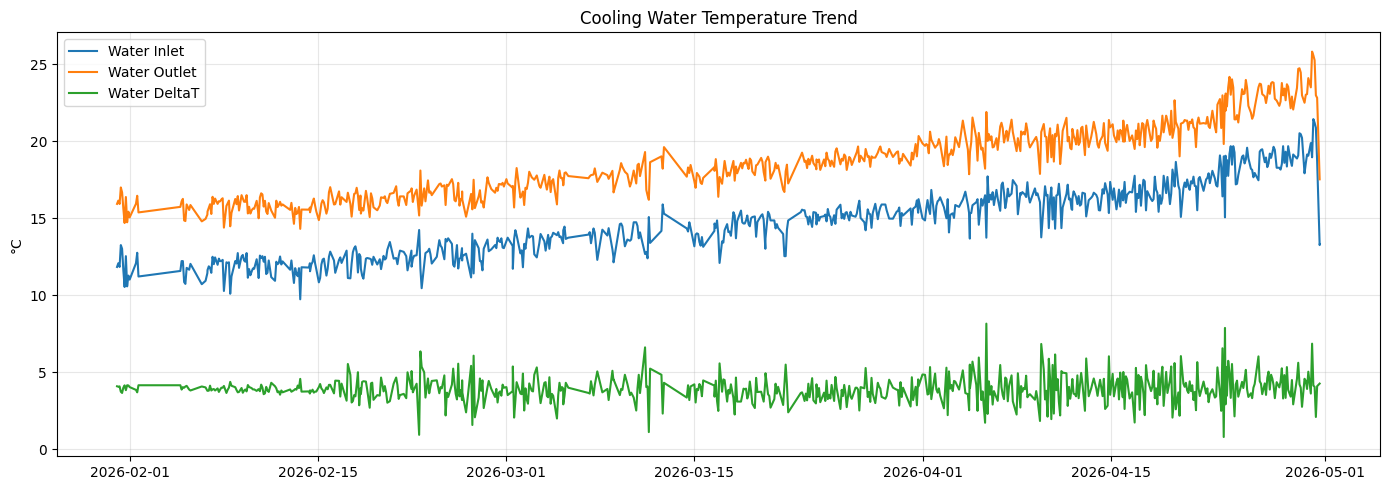

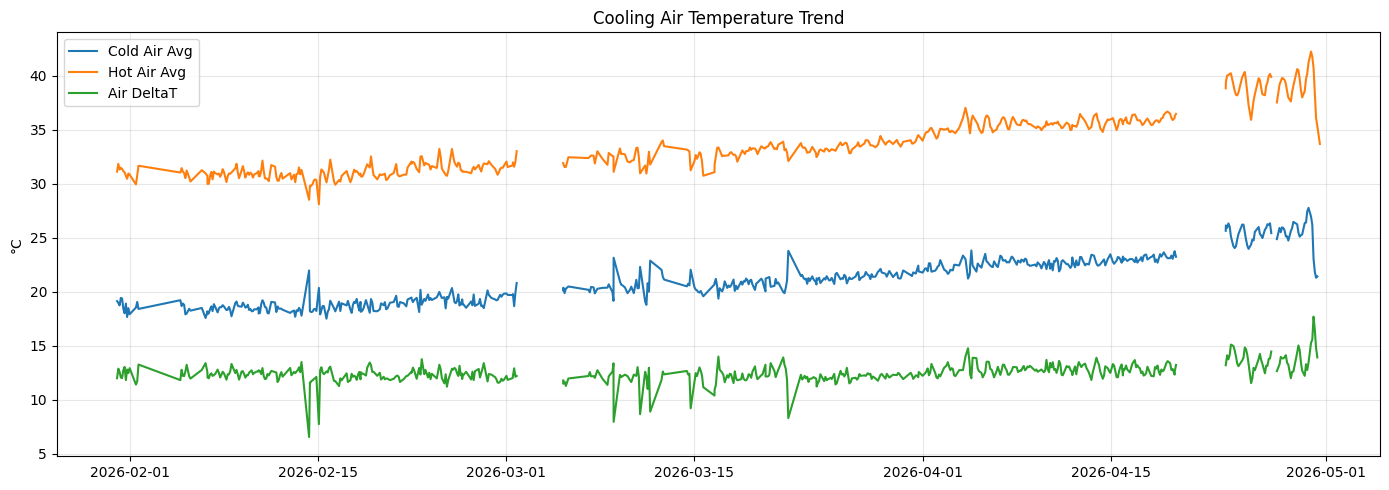

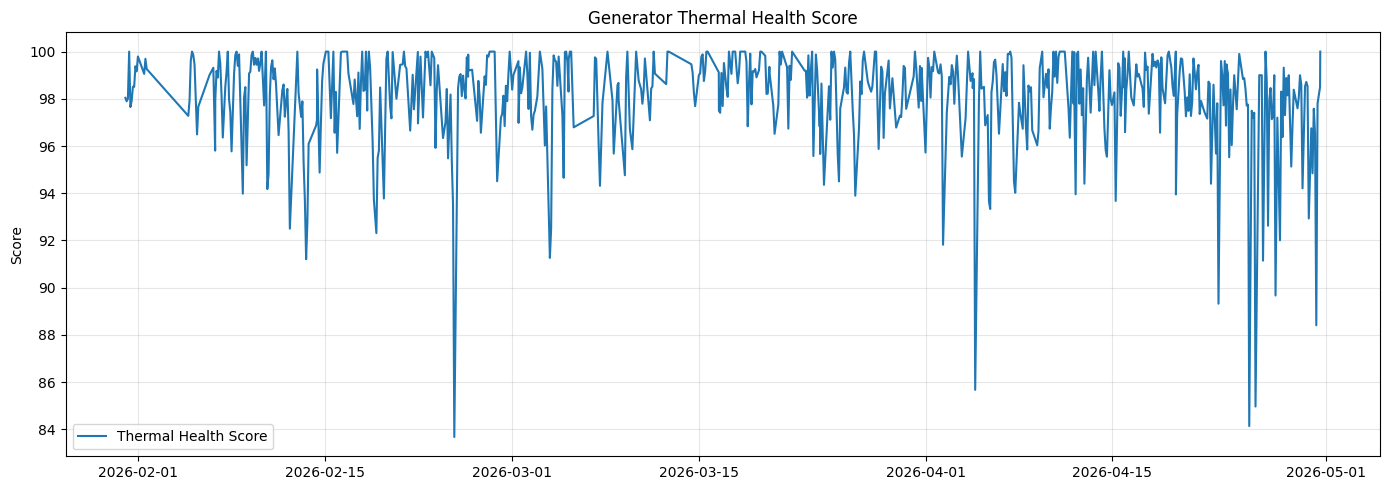

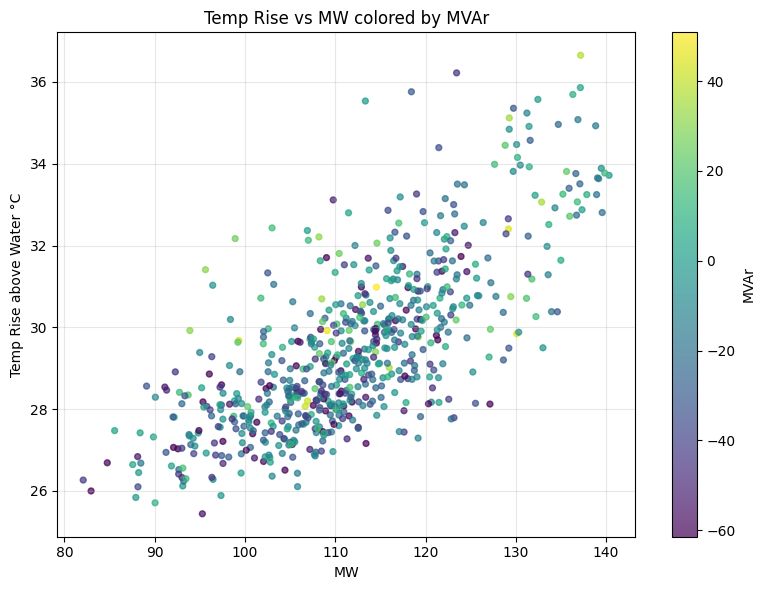

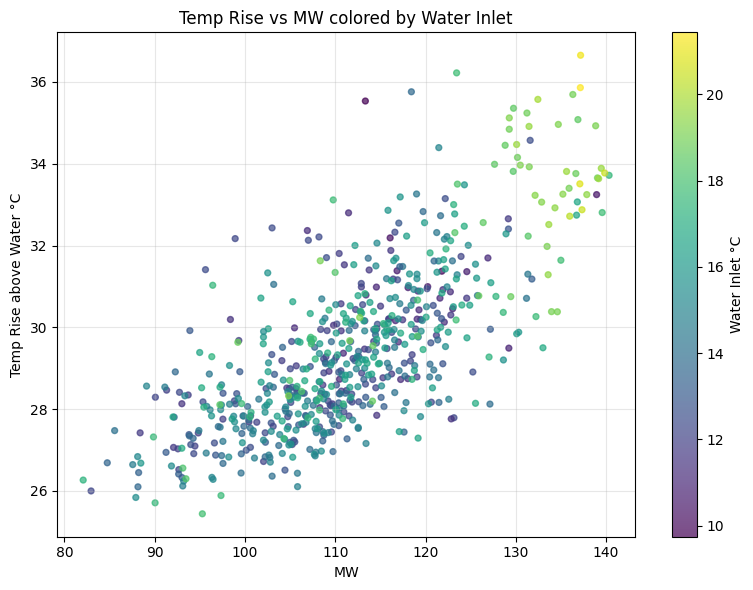

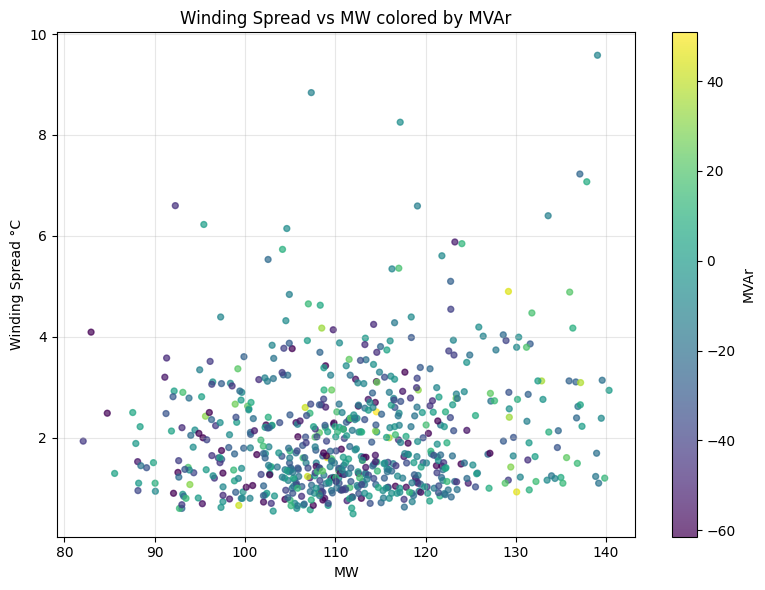

In [ ]:
# =========================================================
# 13. GENERAL PLOTS
# =========================================================

save_time(
    ["MW", "MVAr"],
    ["MW", "MVAr"],
    "Power",
    "Active and Reactive Power Trend",
    "01_power_trend.png"
)

save_time(
    ["Winding_Avg", "Winding_Max", "Core_Avg", "Bearing_Max"],
    ["Winding Avg", "Winding Max", "Core Avg", "Bearing Max"],
    "Temperature °C",
    "Generator Thermal Trend",
    "02_generator_thermal_trend.png"
)

save_time(
    ["Winding_Spread"],
    ["Winding Spread"],
    "°C",
    "Winding Temperature Spread Trend",
    "03_winding_spread_trend.png"
)

save_time(
    ["Water_Inlet", "Water_Outlet", "Water_DeltaT"],
    ["Water Inlet", "Water Outlet", "Water DeltaT"],
    "°C",
    "Cooling Water Temperature Trend",
    "04_cooling_water_trend.png"
)

save_time(
    ["Cold_Air_Avg", "Hot_Air_Avg", "Air_DeltaT"],
    ["Cold Air Avg", "Hot Air Avg", "Air DeltaT"],
    "°C",
    "Cooling Air Temperature Trend",
    "05_air_temperature_trend.png"
)

save_time(
    ["Generator_Thermal_Health_Score"],
    ["Thermal Health Score"],
    "Score",
    "Generator Thermal Health Score",
    "06_health_score.png"
)


save_scatter_colored(
    analysis_df,
    "MW", "TempRise_Avg_vs_Water", "MVAr",
    "MW", "Temp Rise above Water °C", "MVAr",
    "Temp Rise vs MW colored by MVAr",
    "16_temprise_vs_MW_colored_by_MVAr.png"
)

save_scatter_colored(
    analysis_df,
    "MW", "TempRise_Avg_vs_Water", "Water_Inlet",
    "MW", "Temp Rise above Water °C", "Water Inlet °C",
    "Temp Rise vs MW colored by Water Inlet",
    "17_temprise_vs_MW_colored_by_water.png"
)

save_scatter_colored(
    analysis_df,
    "MW", "Winding_Spread", "MVAr",
    "MW", "Winding Spread °C", "MVAr",
    "Winding Spread vs MW colored by MVAr",
    "18_spread_vs_MW_colored_by_MVAr.png"
)


In [ ]:
# =========================================================
# 14. SAME CONDITION SUMMARY
# =========================================================

same_condition_summary = analysis_df.groupby(
    ["MW_bin_10", "MVAr_bin_10", "Water_Inlet_bin"],
    observed=True
).agg(
    Count=("Timestamp", "count"),
    MW_mean=("MW", "mean"),
    MVAr_mean=("MVAr", "mean"),
    Water_Inlet_mean=("Water_Inlet", "mean"),
    Winding_Avg_mean=("Winding_Avg", "mean"),
    Winding_Max_mean=("Winding_Max", "mean"),
    Winding_Spread_mean=("Winding_Spread", "mean"),
    Core_Avg_mean=("Core_Avg", "mean"),
    Bearing_Max_mean=("Bearing_Max", "mean"),
    Water_DeltaT_mean=("Water_DeltaT", "mean"),
    Water_Flow_mean=("Water_Flow", "mean"),
    Cooling_Index_mean=("Cooling_Index_Water", "mean"),
    Health_Score_mean=("Generator_Thermal_Health_Score", "mean"),
).reset_index()

same_condition_summary = same_condition_summary[same_condition_summary["Count"] >= 5]


In [ ]:

# =========================================================
# 15. HOTSPOT SENSOR SUMMARY
# =========================================================

hotspot_count = analysis_df["Winding_Hotspot_Sensor"].value_counts().reset_index()
hotspot_count.columns = ["Sensor", "Hotspot_Count"]

winding_sensor_summary = pd.DataFrame({
    "Sensor": winding_cols,
    "Mean_Temp": [analysis_df[c].mean() for c in winding_cols],
    "Max_Temp": [analysis_df[c].max() for c in winding_cols],
    "Std_Temp": [analysis_df[c].std() for c in winding_cols],
})

winding_sensor_summary = winding_sensor_summary.merge(
    hotspot_count, on="Sensor", how="left"
).fillna(0)

winding_sensor_summary = winding_sensor_summary.sort_values(
    ["Hotspot_Count", "Max_Temp"],
    ascending=False
)


In [ ]:
# =========================================================
# 16. ML THERMAL MODEL
# =========================================================

candidate_features = [
    "MW", "MVAr", "MVAr_abs", "PF_abs", "PF_dev",
    "I_mean", "I_mean_sq", "Copper_loss_proxy",
    "Field_Current", "Field_Current_sq",
    "Water_Inlet", "Water_Flow", "Water_Pressure",
    "Cold_Air_Avg", "Hot_Air_Avg", "Air_DeltaT",
    "TempRise_lag1", "TempRise_lag2", "TempRise_lag3", "TempRise_lag6",
    "TempRise_ewm",
    "MW_lag1", "MW_lag2", "MW_lag3",
    "MVAr_lag1", "MVAr_lag2", "MVAr_lag3",
    "dMW", "dMVAr", "dField_Current",
]

features = [c for c in candidate_features if c in analysis_df.columns]
target_col = "TempRise_Avg_vs_Water"

# Remove initial rows with NaNs from lagged/differenced features
# Max lag is 6 (TempRise_lag6), so drop the first 6 rows
max_lag_rows = 6
temp_analysis_df = analysis_df.iloc[max_lag_rows:].copy()

# First, ensure the target column has no NaNs
model_df = temp_analysis_df.dropna(subset=[target_col]).copy()

# Add a check to ensure model_df is not empty after target dropna
if model_df.empty:
    raise ValueError(f"model_df is empty after dropping NaN values in target_col ('{target_col}'). Consider simplifying the target or source data.")

# For features, fill NaNs using forward-fill, then backward-fill for any leading NaNs
for col in features:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(method='ffill').fillna(method='bfill')

# Remove any features that might still be all NaNs even after ffill/bfill (e.g., if a column was entirely NaN)
initial_features_count = len(features)
features = [f for f in features if f in model_df.columns and not model_df[f].isnull().all()]
if len(features) < initial_features_count:
    print(f"Warning: Removed {initial_features_count - len(features)} features that were entirely NaN after imputation.")
if not features:
    raise ValueError("No valid features remaining after NaN handling.")

# Add a final check to ensure model_df is still not empty after all operations
if model_df.empty:
    raise ValueError("model_df is empty after all NaN handling steps. This indicates a fundamental issue with data completeness.")

X = model_df[features]
y = model_df[target_col]

split_idx = int(len(model_df) * 0.80)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

test_df = model_df.iloc[split_idx:].copy()

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

if XGB_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        objective="reg:squarederror"
    )

metrics_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics_rows.append({
        "Model": name,
        "Train_R2": r2_score(y_train, train_pred),
        "Test_R2": r2_score(y_test, test_pred),
        "Train_MAE_C": mean_absolute_error(y_train, train_pred),
        "Test_MAE_C": mean_absolute_error(y_test, test_pred),
        "Train_RMSE_C": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test_RMSE_C": np.sqrt(mean_squared_error(y_test, test_pred)),
    })

    test_df[f"{name}_Pred"] = test_pred
    test_df[f"{name}_Residual"] = y_test - test_pred

metrics_df = pd.DataFrame(metrics_rows).sort_values("Test_R2", ascending=False)

best_model_name = metrics_df.iloc[0]["Model"]
best_res_col = f"{best_model_name}_Residual"
best_pred_col = f"{best_model_name}_Pred"

print("\nModel performance:")
print(metrics_df.round(4))
print("\nBest model:", best_model_name)

res_thr = test_df[best_res_col].abs().quantile(0.95)
test_df["Residual_Alarm"] = test_df[best_res_col].abs() > res_thr

residual_events = test_df[test_df["Residual_Alarm"]].copy()


/tmp/ipykernel_8985/3679115437.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  model_df[col] = model_df[col].fillna(method='ffill').fillna(method='bfill')



Model performance:
              Model  Train_R2  Test_R2  Train_MAE_C  Test_MAE_C  Train_RMSE_C  \
0  LinearRegression    0.6686   0.6596       0.7262      1.1557        0.9650   
1      RandomForest    0.8316   0.5687       0.4912      1.3947        0.6879   
2           XGBoost    0.9994   0.4396       0.0291      1.5930        0.0396   

   Test_RMSE_C  
0       1.5006  
1       1.6891  
2       1.9254  

Best model: LinearRegression


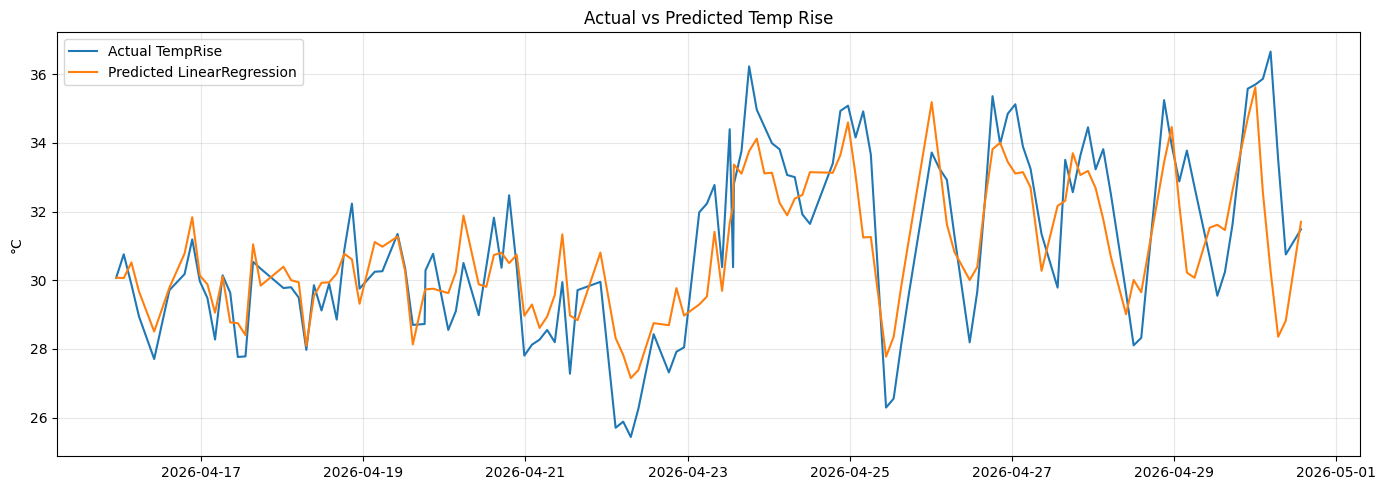

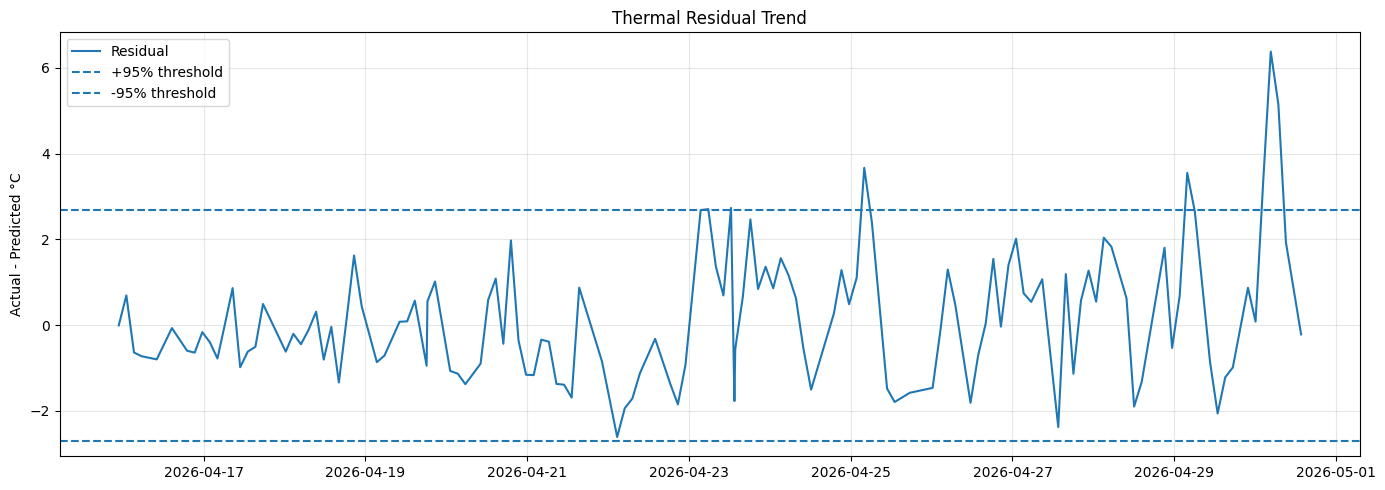

In [ ]:
# =========================================================
# 17. RESIDUAL PLOTS
# =========================================================

plt.figure(figsize=(14, 5))
plt.plot(test_df["Timestamp"], test_df[target_col], label="Actual TempRise")
plt.plot(test_df["Timestamp"], test_df[best_pred_col], label=f"Predicted {best_model_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Actual vs Predicted Temp Rise")
plt.ylabel("°C")
plt.tight_layout()
plt.savefig(output_dir / "19_actual_vs_predicted_temprise.png", dpi=200)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(test_df["Timestamp"], test_df[best_res_col], label="Residual")
plt.axhline(res_thr, linestyle="--", label="+95% threshold")
plt.axhline(-res_thr, linestyle="--", label="-95% threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Thermal Residual Trend")
plt.ylabel("Actual - Predicted °C")
plt.tight_layout()
plt.savefig(output_dir / "20_thermal_residual_trend.png", dpi=200)
plt.show()


In [ ]:
# =========================================================
# 18. DAILY SUMMARY
# =========================================================

analysis_df["Date"] = analysis_df["Timestamp"].dt.date

daily_summary = analysis_df.groupby("Date").agg(
    MW_mean=("MW", "mean"),
    MW_max=("MW", "max"),
    MVAr_mean=("MVAr", "mean"),
    PF_mean=("PF_abs", "mean"),
    Winding_Avg_mean=("Winding_Avg", "mean"),
    Winding_Max_max=("Winding_Max", "max"),
    Winding_Spread_mean=("Winding_Spread", "mean"),
    Winding_Spread_max=("Winding_Spread", "max"),
    Core_Avg_mean=("Core_Avg", "mean"),
    Bearing_Max_mean=("Bearing_Max", "mean"),
    Water_Inlet_mean=("Water_Inlet", "mean"),
    Water_DeltaT_mean=("Water_DeltaT", "mean"),
    Water_Flow_mean=("Water_Flow", "mean"),
    Cooling_Index_mean=("Cooling_Index_Water", "mean"),
    Health_Score_mean=("Generator_Thermal_Health_Score", "mean"),
).reset_index()


In [ ]:
# =========================================================
# 19. SAVE OUTPUTS
# =========================================================

analysis_df.to_csv(output_dir / "merged_general_analysis_dataset.csv", index=False)
same_condition_summary.to_csv(output_dir / "same_condition_summary.csv", index=False)
winding_sensor_summary.to_csv(output_dir / "winding_hotspot_sensor_summary.csv", index=False)
daily_summary.to_csv(output_dir / "daily_summary.csv", index=False)
metrics_df.to_csv(output_dir / "model_metrics.csv", index=False)
test_df.to_csv(output_dir / "model_test_predictions.csv", index=False)
residual_events.to_csv(output_dir / "thermal_residual_alarm_events.csv", index=False)

with pd.ExcelWriter(output_dir / "UNIT3_Generator_General_Analysis.xlsx", engine="openpyxl") as writer:
    analysis_df.to_excel(writer, sheet_name="Merged_Analysis", index=False)
    same_condition_summary.to_excel(writer, sheet_name="Same_Condition", index=False)
    winding_sensor_summary.to_excel(writer, sheet_name="Winding_Hotspots", index=False)
    daily_summary.to_excel(writer, sheet_name="Daily_Summary", index=False)
    metrics_df.to_excel(writer, sheet_name="Model_Metrics", index=False)
    residual_events.to_excel(writer, sheet_name="Residual_Alarms", index=False)




In [ ]:

# =========================================================
# 20. QUICK RESULTS
# =========================================================

print("\n===== QUICK RESULTS =====")
print("Date range:", analysis_df["Timestamp"].min(), "to", analysis_df["Timestamp"].max())
print("Rows analyzed:", len(analysis_df))
print("Average MW:", round(analysis_df["MW"].mean(), 2))
print("Average MVAr:", round(analysis_df["MVAr"].mean(), 2))
print("Average winding avg:", round(analysis_df["Winding_Avg"].mean(), 2), "°C")
print("Max winding:", round(analysis_df["Winding_Max"].max(), 2), "°C")
print("Average winding spread:", round(analysis_df["Winding_Spread"].mean(), 2), "°C")
print("Max winding spread:", round(analysis_df["Winding_Spread"].max(), 2), "°C")
print("Average core:", round(analysis_df["Core_Avg"].mean(), 2), "°C")
print("Average bearing max:", round(analysis_df["Bearing_Max"].mean(), 2), "°C")
print("Average water deltaT:", round(analysis_df["Water_DeltaT"].mean(), 2), "°C")
print("Average cooling index:", round(analysis_df["Cooling_Index_Water"].mean(), 4))
print("Average health score:", round(analysis_df["Generator_Thermal_Health_Score"].mean(), 2))
print("Best ML model:", best_model_name)
print("Residual alarm threshold:", round(res_thr, 3), "°C")
print("Residual alarm events:", len(residual_events))
print("\nFiles saved in:", output_dir.resolve())
print("\nDone.")



===== QUICK RESULTS =====
Date range: 2026-01-31 00:39:00 to 2026-04-30 14:01:00
Rows analyzed: 655
Average MW: 111.77
Average MVAr: -17.26
Average winding avg: 44.22 °C
Max winding: 59.0 °C
Average winding spread: 2.03 °C
Max winding spread: 9.58 °C
Average core: 45.6 °C
Average bearing max: 68.35 °C
Average water deltaT: 3.92 °C
Average cooling index: 0.2651
Average health score: 98.15
Best ML model: LinearRegression
Residual alarm threshold: 2.695 °C
Residual alarm events: 7

Files saved in: /content/UNIT1_generator_general_analysis_outputs

Done.


In [ ]:
# =========================================================
# EXTRA ELECTRICAL ANALYSIS MODULE
# =========================================================

# ---------- Current balance ----------
analysis_df["I_A"] = analysis_df["UNIT CURRENT PHASE A"]
analysis_df["I_B"] = analysis_df["UNIT CURRENT PHASE B"]
analysis_df["I_C"] = analysis_df["UNIT CURRENT PHASE C"]

analysis_df["I_mean"] = analysis_df[["I_A", "I_B", "I_C"]].mean(axis=1)
analysis_df["I_max"] = analysis_df[["I_A", "I_B", "I_C"]].max(axis=1)
analysis_df["I_min"] = analysis_df[["I_A", "I_B", "I_C"]].min(axis=1)

analysis_df["Current_Imbalance_pct"] = (
    (analysis_df["I_max"] - analysis_df["I_min"]) / analysis_df["I_mean"] * 100
)

# ---------- Voltage balance ----------
analysis_df["V_AB"] = analysis_df["UNIT VOLTAGE PHASE AB"]
analysis_df["V_BC"] = analysis_df["UNIT VOLTAGE PHASE BC"]
analysis_df["V_CA"] = analysis_df["UNIT VOLTAGE PHASE CA"]

analysis_df["V_mean"] = analysis_df[["V_AB", "V_BC", "V_CA"]].mean(axis=1)
analysis_df["V_max"] = analysis_df[["V_AB", "V_BC", "V_CA"]].max(axis=1)
analysis_df["V_min"] = analysis_df[["V_AB", "V_BC", "V_CA"]].min(axis=1)

analysis_df["Voltage_Imbalance_pct"] = (
    (analysis_df["V_max"] - analysis_df["V_min"]) / analysis_df["V_mean"] * 100
)

# ---------- Excitation ----------
analysis_df["Field_Current"] = analysis_df["FIELD CURRENT"]
analysis_df["Field_Voltage"] = analysis_df["FIELD VOLTAGE"]

analysis_df["Field_Current_per_MW"] = analysis_df["Field_Current"] / analysis_df["MW"]
analysis_df["Field_Current_per_MVAr_abs"] = analysis_df["Field_Current"] / analysis_df["MVAr_abs"].replace(0, np.nan)

# ---------- Electrical loading ----------
analysis_df["MVA"] = np.sqrt(analysis_df["MW"]**2 + analysis_df["MVAr"]**2)
analysis_df["PF_abs"] = analysis_df["MW"].abs() / analysis_df["MVA"]

analysis_df["I2R_proxy"] = analysis_df["I_mean"] ** 2
analysis_df["Copper_Loss_Proxy"] = (
    analysis_df["I_A"]**2 +
    analysis_df["I_B"]**2 +
    analysis_df["I_C"]**2
)

analysis_df["I_per_MW"] = analysis_df["I_mean"] / analysis_df["MW"]

# ---------- Over-excitation / under-excitation ----------
field_high = analysis_df["Field_Current"].quantile(0.90)
field_low = analysis_df["Field_Current"].quantile(0.10)
mvar_high = analysis_df["MVAr_abs"].quantile(0.90)

analysis_df["High_Field_Current_Flag"] = analysis_df["Field_Current"] > field_high
analysis_df["Low_Field_Current_Flag"] = analysis_df["Field_Current"] < field_low
analysis_df["High_MVAr_Flag"] = analysis_df["MVAr_abs"] > mvar_high

analysis_df["Possible_OverExcitation_Flag"] = (
    analysis_df["High_Field_Current_Flag"] &
    analysis_df["High_MVAr_Flag"]
)

# ---------- Electrical thermal influence ----------
analysis_df["Electrical_Stress_Index"] = (
    analysis_df["I2R_proxy"] *
    analysis_df["Field_Current"] *
    analysis_df["PF_dev"].fillna(0)
)

# Normalize for easier comparison
analysis_df["Electrical_Stress_Index_Norm"] = (
    analysis_df["Electrical_Stress_Index"] /
    analysis_df["Electrical_Stress_Index"].median()
)


/tmp/ipykernel_8985/3139958978.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  analysis_df["Electrical_Stress_Index_Norm"] = (


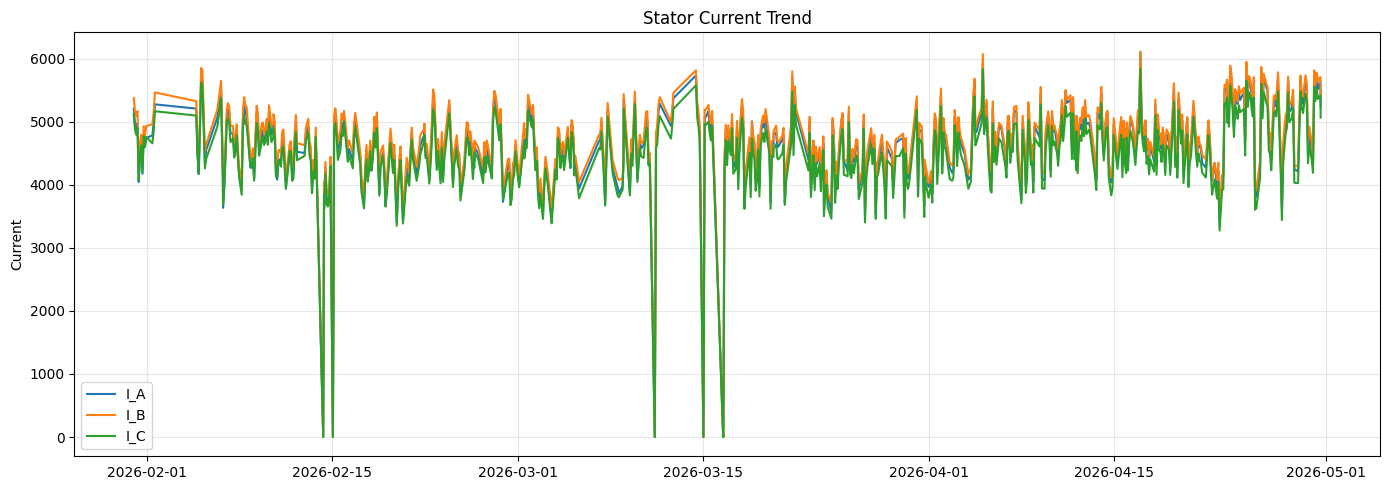

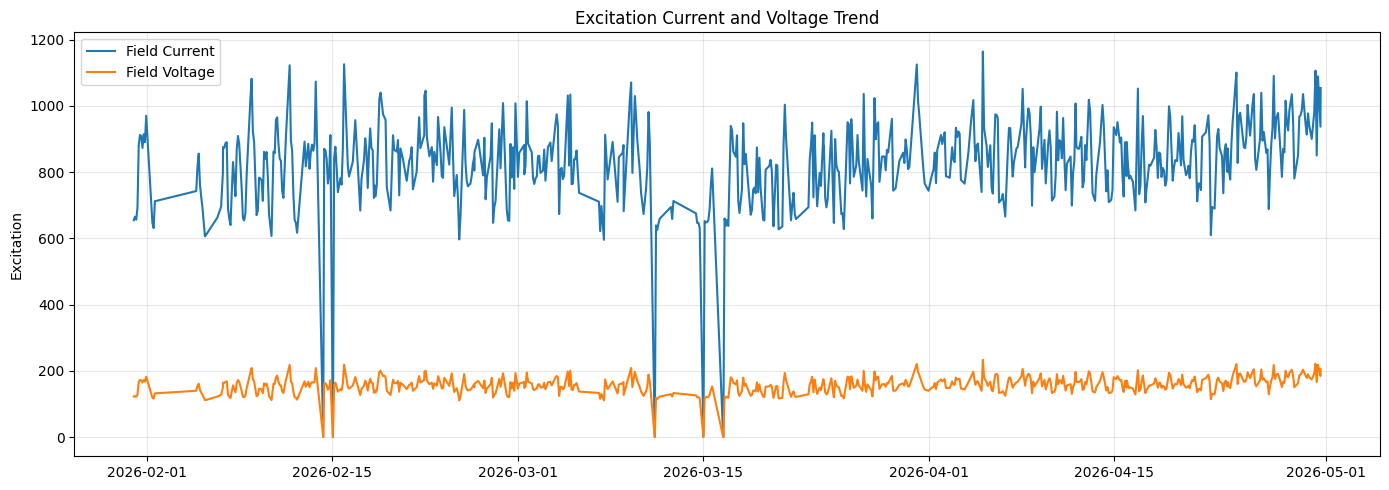

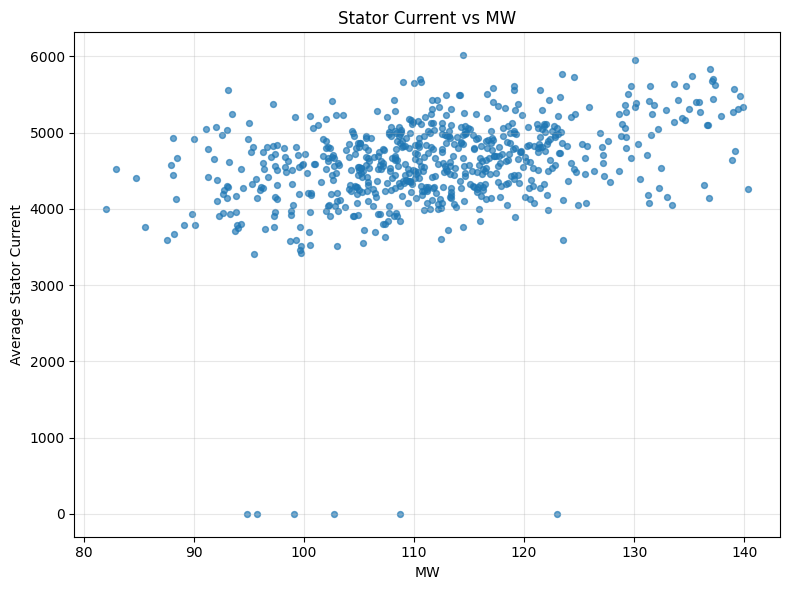

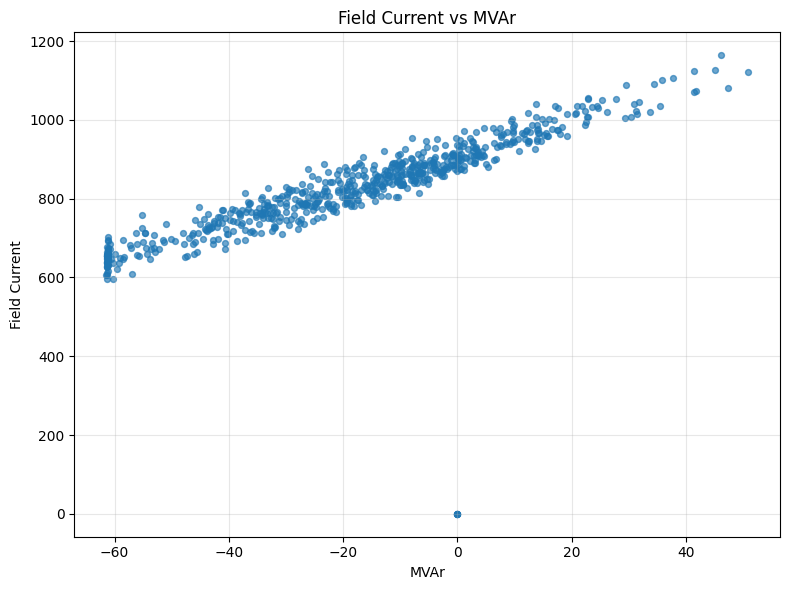

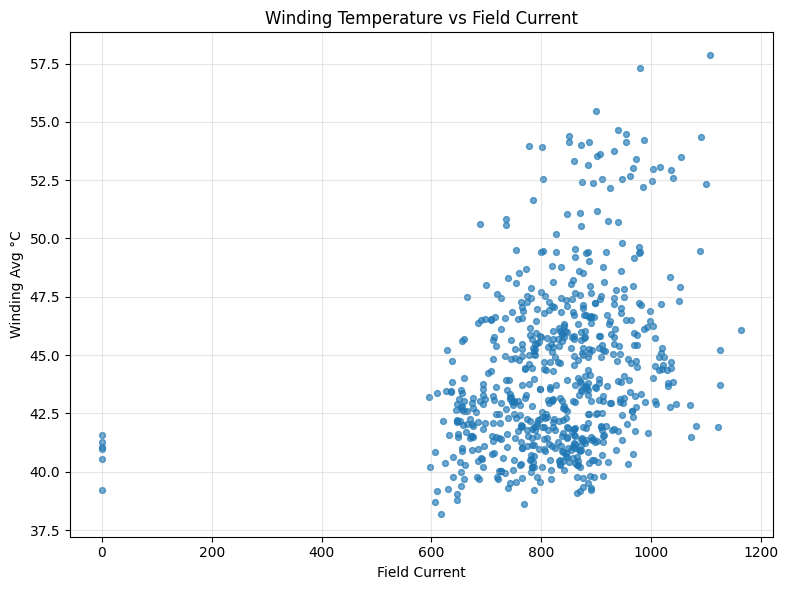

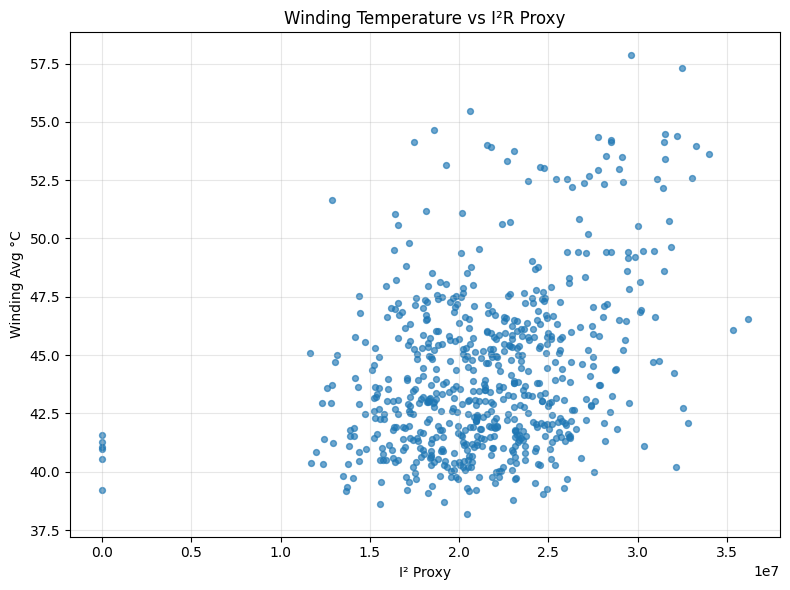

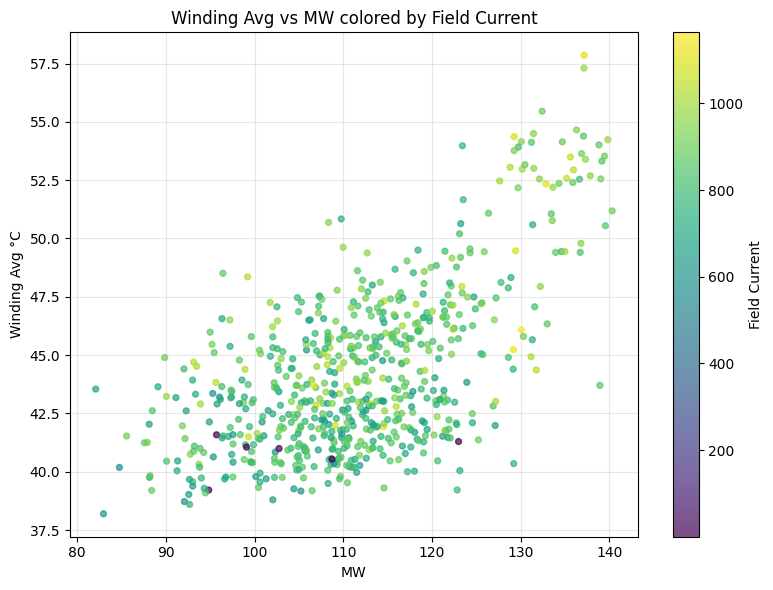

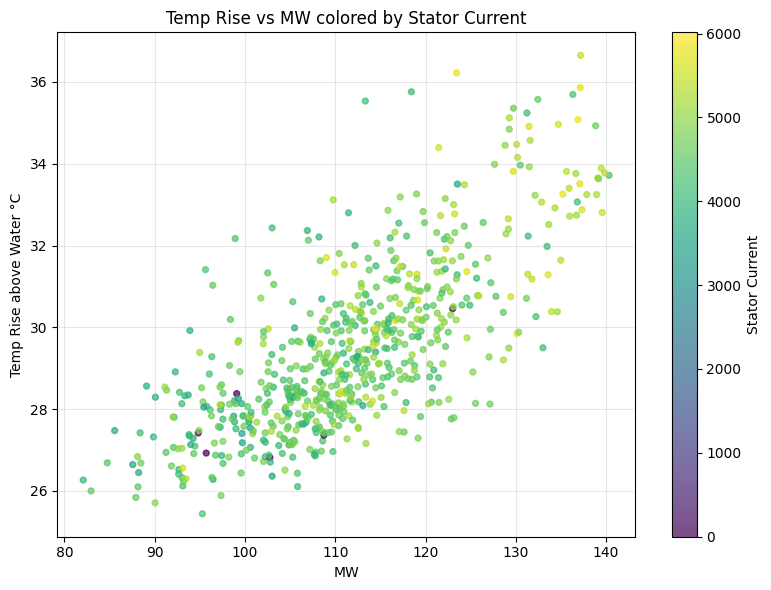

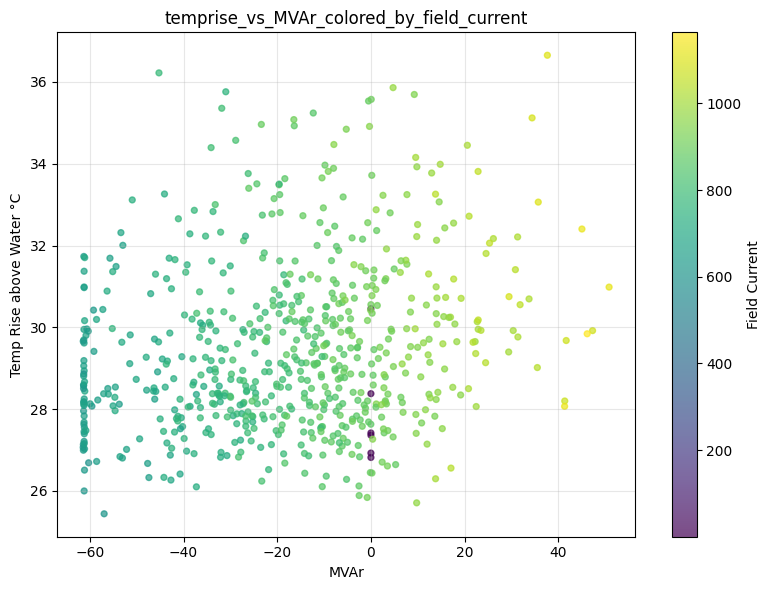

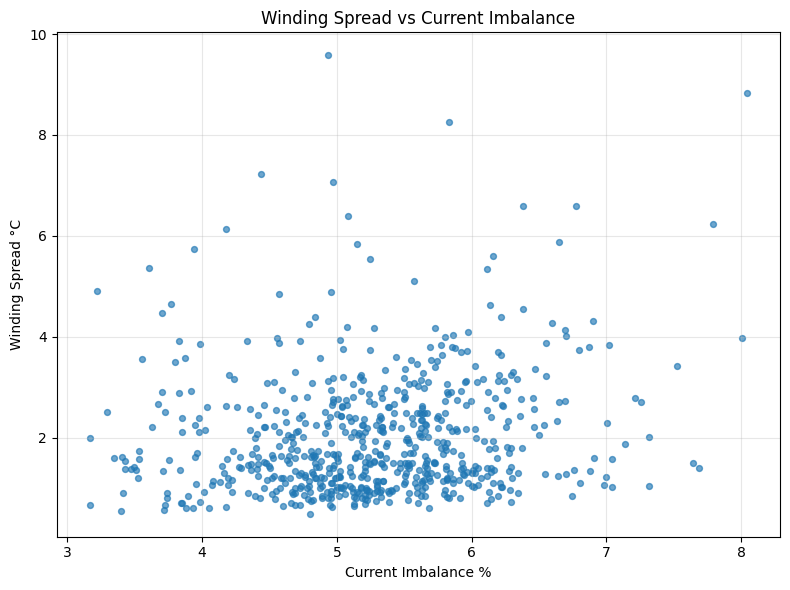

In [ ]:
save_time(
    ["I_A", "I_B", "I_C"],
    ["I_A", "I_B", "I_C"],
    "Current",
    "Stator Current Trend",
    "21_stator_current_trend.png"
)

save_time(
    ["Field_Current", "Field_Voltage"],
    ["Field Current", "Field Voltage"],
    "Excitation",
    "Excitation Current and Voltage Trend",
    "22_excitation_trend.png"
)

save_scatter(
    analysis_df, "MW", "I_mean",
    "MW", "Average Stator Current",
    "Stator Current vs MW",
    "23_current_vs_MW.png"
)

save_scatter(
    analysis_df, "MVAr", "Field_Current",
    "MVAr", "Field Current",
    "Field Current vs MVAr",
    "24_field_current_vs_MVAr.png"
)

save_scatter(
    analysis_df, "Field_Current", "Winding_Avg",
    "Field Current", "Winding Avg °C",
    "Winding Temperature vs Field Current",
    "25_winding_vs_field_current.png"
)

save_scatter(
    analysis_df, "I2R_proxy", "Winding_Avg",
    "I² Proxy", "Winding Avg °C",
    "Winding Temperature vs I²R Proxy",
    "26_winding_vs_I2R.png"
)

save_scatter_colored(analysis_df,
    "MW", "Winding_Avg", "Field_Current",
    "MW", "Winding Avg °C", "Field Current",
    "Winding Avg vs MW colored by Field Current",
    "27_winding_vs_MW_colored_by_field_current.png"
)

save_scatter_colored(analysis_df,
    "MW", "TempRise_Avg_vs_Water", "I_mean",
    "MW", "Temp Rise above Water °C", "Stator Current",
    "Temp Rise vs MW colored by Stator Current",
    "28_temprise_vs_MW_colored_by_current.png"
)

save_scatter_colored(analysis_df,
    "MVAr", "TempRise_Avg_vs_Water", "Field_Current",
    "MVAr", "Temp Rise above Water °C", "Field Current",
    "temprise_vs_MVAr_colored_by_field_current",
    "29_temprise_vs_MVAr_colored_by_field_current.png"
)

save_scatter(
    analysis_df, "Current_Imbalance_pct", "Winding_Spread",
    "Current Imbalance %", "Winding Spread °C",
    "Winding Spread vs Current Imbalance",
    "30_spread_vs_current_imbalance.png"
)

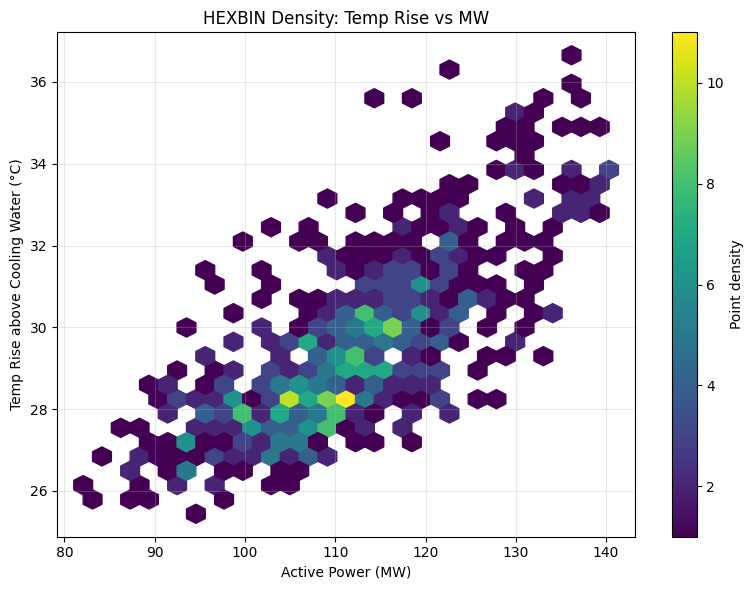

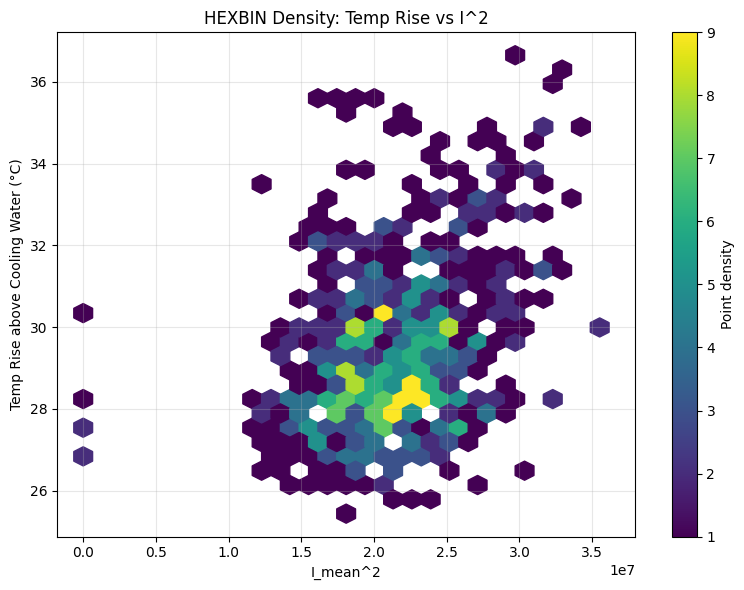

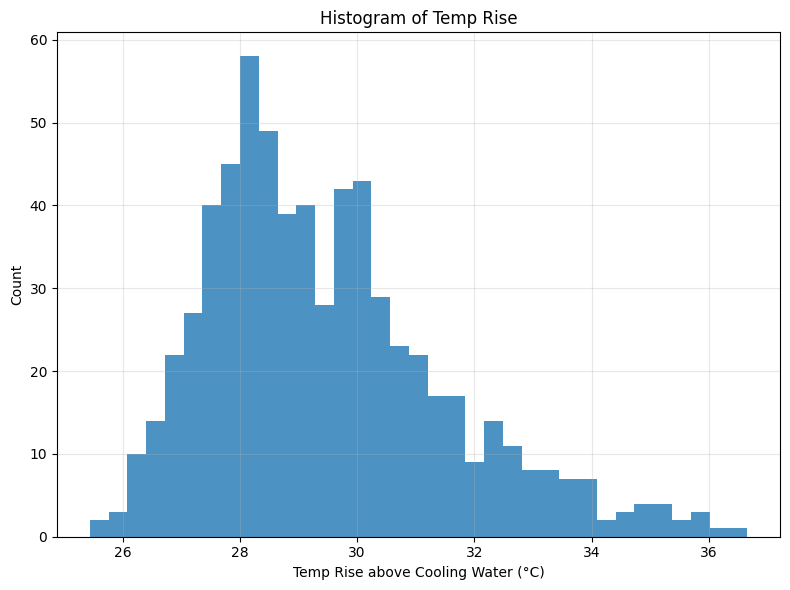

/tmp/ipykernel_8985/3842899411.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


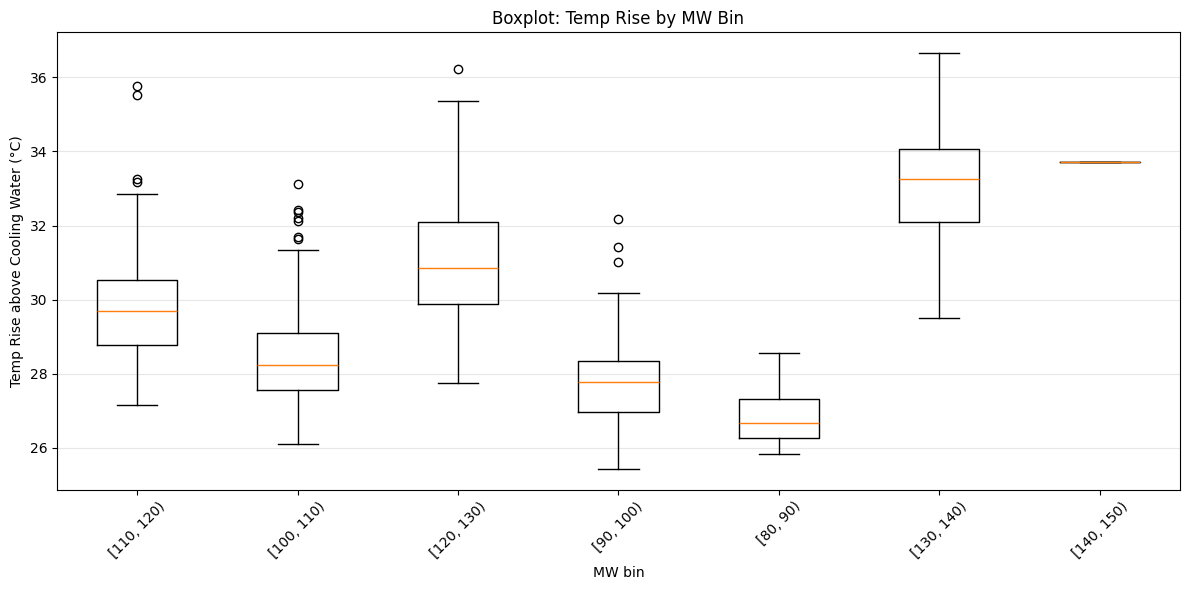

/tmp/ipykernel_8985/3842899411.py:108: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = plot_df.pivot_table(


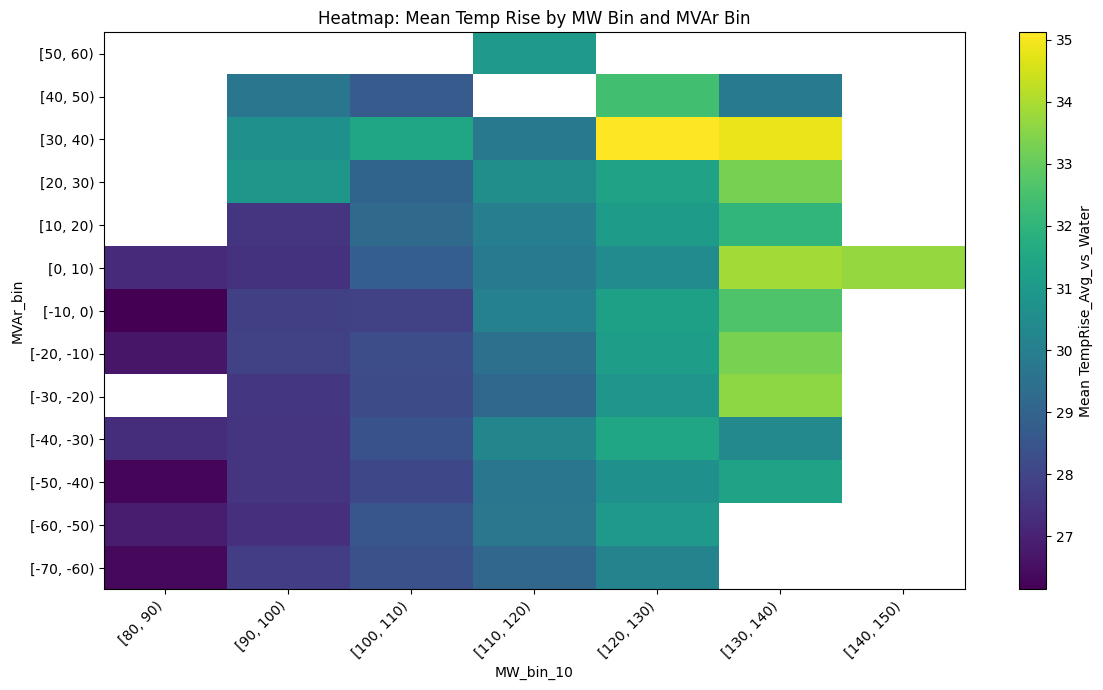

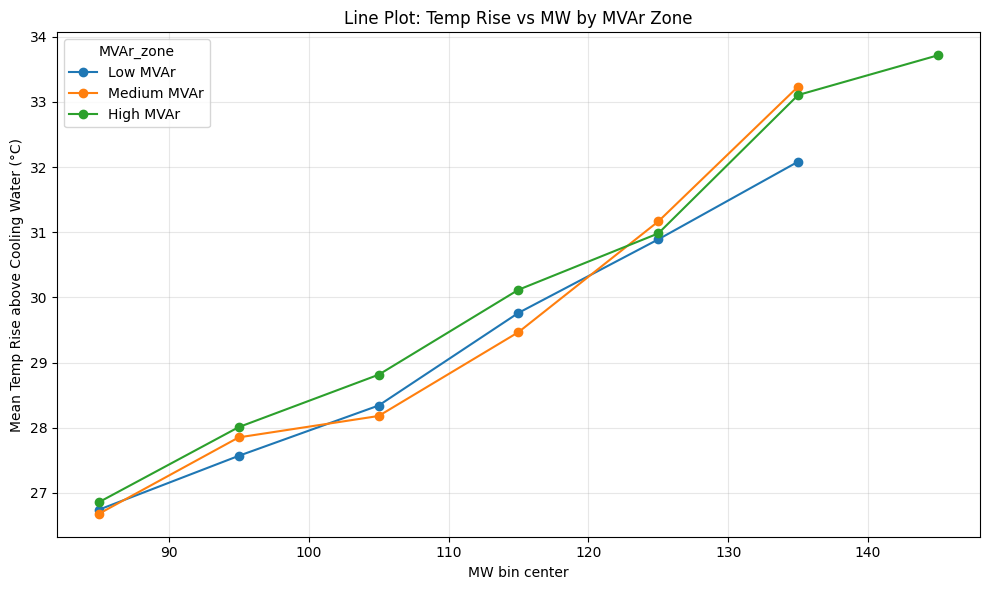

In [ ]:
# =========================================================
# 17. NEW BETTER ILLUSTRATION PLOTS
# =========================================================
save_hexbin(
    analysis_df,
    x="MW",
    y="TempRise_Avg_vs_Water",
    xlabel="Active Power (MW)",
    ylabel="Temp Rise above Cooling Water (°C)",
    title="HEXBIN Density: Temp Rise vs MW",
    filename="08_hexbin_temprise_vs_MW.png"
)

save_hexbin(
    analysis_df,
    x="I_mean_sq",
    y="TempRise_Avg_vs_Water",
    xlabel="I_mean^2",
    ylabel="Temp Rise above Cooling Water (°C)",
    title="HEXBIN Density: Temp Rise vs I^2",
    filename="09_hexbin_temprise_vs_I2.png"
)

save_hist(
    analysis_df["TempRise_Avg_vs_Water"],
    xlabel="Temp Rise above Cooling Water (°C)",
    title="Histogram of Temp Rise",
    filename="10_hist_temprise.png",
    bins=35
)

save_boxplot_by_bin(
    analysis_df,
    bin_col="MW_bin_10",
    y_col="TempRise_Avg_vs_Water",
    xlabel="MW bin",
    ylabel="Temp Rise above Cooling Water (°C)",
    title="Boxplot: Temp Rise by MW Bin",
    filename="11_boxplot_temprise_by_MWbin.png"
)

save_heatmap_from_bins(
    analysis_df.assign(
        MVAr_bin=pd.cut(analysis_df["MVAr"], bins=np.arange(-80, 61, 10), right=False)
    ),
    x_bin_col="MW_bin_10",
    y_bin_col="MVAr_bin",
    value_col="TempRise_Avg_vs_Water",
    title="Heatmap: Mean Temp Rise by MW Bin and MVAr Bin",
    filename="12_heatmap_MW_MVAr_temprise.png"
)

# For line plot, use MW-bin centers
line_df = analysis_df.copy()
line_df["MW_bin_mid"] = line_df["MW_bin_10"].apply(lambda x: x.mid if pd.notna(x) else np.nan)

# Adding a simplified MVAr_zone for demonstration if it's not already defined
# (Assuming `MVAr_zone` is meant to categorize MVAr ranges for the line plot)
# If MVAr_zone is not present, create a simple one or use an existing categorical column
if "MVAr_zone" not in line_df.columns:
    line_df["MVAr_zone"] = pd.qcut(line_df["MVAr"], q=3, labels=["Low MVAr", "Medium MVAr", "High MVAr"])

save_line_by_group(
    line_df,
    x_col="MW_bin_mid",
    y_col="TempRise_Avg_vs_Water",
    group_col="MVAr_zone",
    xlabel="MW bin center",
    ylabel="Mean Temp Rise above Cooling Water (°C)",
    title="Line Plot: Temp Rise vs MW by MVAr Zone",
    filename="13_line_temprise_by_MW_and_MVArzone.png"
)

In [ ]:
I_mean=("I_mean", "mean"),
I_max=("I_max", "max"),
Current_Imbalance_mean=("Current_Imbalance_pct", "mean"),
Current_Imbalance_max=("Current_Imbalance_pct", "max"),
Voltage_Imbalance_mean=("Voltage_Imbalance_pct", "mean"),
Field_Current_mean=("Field_Current", "mean"),
Field_Current_max=("Field_Current", "max"),
Field_Current_per_MW_mean=("Field_Current_per_MW", "mean"),
PF_mean=("PF_abs", "mean"),
I2R_proxy_mean=("I2R_proxy", "mean"),
Electrical_Stress_Index_mean=("Electrical_Stress_Index_Norm", "mean"),
OverExcitation_count=("Possible_OverExcitation_Flag", "sum"),
